# <font color=darkred>Laboratory 15: Pandas for Butter! </font>

In [1]:
# Preamble script block to identify host, user, and kernel
import sys
! hostname
! whoami
print(sys.executable)
print(sys.version)
print(sys.version_info)

GouldPC
gouldpc\gould
C:\Users\gould\anaconda3\python.exe
3.12.4 | packaged by Anaconda, Inc. | (main, Jun 18 2024, 15:03:56) [MSC v.1929 64 bit (AMD64)]
sys.version_info(major=3, minor=12, micro=4, releaselevel='final', serial=0)


## Full name: Graysen Gould
## R#: 11944656
## Title of the notebook: Laboratory 15: Pandas for Butter!
## Date: 11-4-24
___

![](https://upload.wikimedia.org/wikipedia/commons/thumb/e/ed/Pandas_logo.svg/1280px-Pandas_logo.svg.png) <br>

## <font color=purple>Pandas</font>
A data table is called a `DataFrame` in pandas (and other programming environments too).

The figure below from https://pandas.pydata.org/docs/getting_started/index.html illustrates a dataframe model:

![](https://pandas.pydata.org/docs/_images/01_table_dataframe.svg) 

Each column and each row in a dataframe is called a series, the header row, and index column are special.

To use pandas, we need to import the module, generally pandas has numpy as a dependency so it also must be imported



In [2]:
import numpy as np #Importing NumPy library as "np"
import pandas as pd #Importing Pandas library as "pd"

___
### <font color=darkgreen>Dataframe-structure using primative python</font>

First lets construct a dataframe like object using python primatives.
We will construct 3 lists, one for row names, one for column names, and one for the content.

In [3]:
mytabular = np.random.randint(1,100,(5,4))
myrowname = ['A','B','C','D','E']
mycolname = ['W','X','Y','Z']
mytable = [['' for jcol in range(len(mycolname)+1)] for irow in range(len(myrowname)+1)] #non-null destination matrix, note the implied loop construction

In [4]:
print(mytabular)

[[ 5 72 29  1]
 [17 34 18 57]
 [16  5 78 87]
 [45 24 60 11]
 [19 61 57 29]]


The above builds a placeholder named `mytable` for the psuedo-dataframe.
Next we populate the table, using a for loop to write the column names in the first row, row names in the first column, and the table fill for the rest of the table.

In [6]:
for irow in range(1,len(myrowname)+1): # write the row names
    mytable[irow][0]=myrowname[irow-1]
for jcol in range(1,len(mycolname)+1): # write the column names
    mytable[0][jcol]=mycolname[jcol-1]  
for irow in range(1,len(myrowname)+1): # fill the table (note the nested loop)
    for jcol in range(1,len(mycolname)+1):
        mytable[irow][jcol]=mytabular[irow-1][jcol-1]

Now lets print the table out by row and we see we have a very dataframe-like structure

In [7]:
for irow in range(0,len(myrowname)+1):
    print(mytable[irow][0:len(mycolname)+1])

['', 'W', 'X', 'Y', 'Z']
['A', 82, 25, 29, 67]
['B', 60, 90, 23, 84]
['C', 33, 29, 95, 62]
['D', 19, 68, 64, 21]
['E', 86, 37, 40, 58]


We can also query by row 

In [8]:
print(mytable[3][0:len(mycolname)+1])

['C', 33, 29, 95, 62]


Or by column

In [9]:
for irow in range(0,len(myrowname)+1):  #cannot use implied loop in a column slice
    print(mytable[irow][2])

X
25
90
29
68
37


Or by row+column index; sort of looks like a spreadsheet syntax.

In [10]:
print(' ',mytable[0][3])
print(mytable[3][0],mytable[3][3])

  Y
C 95


___
### <font color=darkgreen>Create a proper dataframe</font>
We will now do the same using pandas

In [11]:
df = pd.DataFrame(np.random.randint(1,100,(5,4)), ['A','B','C','D','E'], ['W','X','Y','Z'])
df

,W,X,Y,Z
A,59,93,64,4
B,35,9,29,45
C,58,88,75,81
D,82,38,31,99
E,54,53,69,90


We can also turn our table into a dataframe, notice how the constructor adds header row and index column

In [12]:
df1 = pd.DataFrame(mytable)
df1

,0,1,2,3,4
0,,W,X,Y,Z
1,A,82,25,29,67
2,B,60,90,23,84
3,C,33,29,95,62
4,D,19,68,64,21
5,E,86,37,40,58


To get proper behavior, we can just reuse our original objects

In [13]:
df2 = pd.DataFrame(mytabular,myrowname,mycolname)
df2

,W,X,Y,Z
A,82,25,29,67
B,60,90,23,84
C,33,29,95,62
D,19,68,64,21
E,86,37,40,58


___
## <font color=purple>Getting the shape of dataframes</font>

The shape method will return the row and column rank (count) of a dataframe.


In [14]:
df.shape

(5, 4)

In [15]:
df1.shape

(6, 5)

In [16]:
df2.shape

(5, 4)

___
## <font color=purple>Appending new columns</font>
To append a column simply assign a value to a new column name to the dataframe

In [17]:
df['new']= 'NA'
df

,W,X,Y,Z,new
A,59,93,64,4,NA
B,35,9,29,45,NA
C,58,88,75,81,NA
D,82,38,31,99,NA
E,54,53,69,90,NA


___
## <font color=purple>Appending new rows</font>
A bit trickier but we can create a copy of a row and concatenate it back into the dataframe.

In [18]:
newrow = df.loc[['E']].rename(index={"E": "X"}) # create a single row, rename the index
newtable = pd.concat([df,newrow]) # concatenate the row to bottom of df - note the syntax

In [19]:
newtable

,W,X,Y,Z,new
A,59,93,64,4,NA
B,35,9,29,45,NA
C,58,88,75,81,NA
D,82,38,31,99,NA
E,54,53,69,90,NA
X,54,53,69,90,NA


___
## <font color=purple>Removing Rows and Columns</font>

To remove a column is straightforward, we use the drop method

In [20]:
newtable.drop('new', axis=1, inplace = True)
newtable

,W,X,Y,Z
A,59,93,64,4
B,35,9,29,45
C,58,88,75,81
D,82,38,31,99
E,54,53,69,90
X,54,53,69,90


To remove a row, you really got to want to, easiest is probablty to create a new dataframe with the row removed

In [21]:
newtable = newtable.loc[['A','B','D','E','X']] # select all rows except C
newtable

,W,X,Y,Z
A,59,93,64,4
B,35,9,29,45
D,82,38,31,99
E,54,53,69,90
X,54,53,69,90


___
## <font color=purple>Indexing</font>
We have already been indexing, but a few examples follow:

In [22]:
newtable['X'] #Selecing a single column

A    93
B     9
D    38
E    53
X    53
Name: X, dtype: int32

In [23]:
newtable[['X','W']] #Selecing multiple columns

,X,W
A,93,59
B,9,35
D,38,82
E,53,54
X,53,54


In [24]:
newtable.loc['E'] #Selecing rows based on label via loc[ ] indexer

W    54
X    53
Y    69
Z    90
Name: E, dtype: int32

In [25]:
newtable.loc[['E','X','B']] #Selecing multiple rows based on label via loc[ ] indexer

,W,X,Y,Z
E,54,53,69,90
X,54,53,69,90
B,35,9,29,45


In [26]:
newtable.loc[['B','E','D'],['X','Y']] #Selecting elemens via both rows and columns via loc[ ] indexer

,X,Y
B,9,29
E,53,69
D,38,31


## Inclass Excersise

#### Q1 Read in the titanic dataset 

In [27]:
titanic_data = pd.read_csv("train_clean.csv")
titanic_data.head()

,Age,Cabin,Embarked,Fare,Name,Parch,PassengerId,Pclass,Sex,SibSp,Survived,Ticket,Title,Family_Size
0,22.0,NaN,S,7.2500,"Braund, Mr. Owen Harris",0,1,3,male,1,0,A/5 21171,Mr,1
1,38.0,C85,C,71.2833,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,2,1,female,1,1,PC 17599,Mrs,1
2,26.0,NaN,S,7.9250,"Heikkinen, Miss. Laina",0,3,3,female,0,1,STON/O2. 3101282,Miss,0
3,35.0,C123,S,53.1000,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,4,1,female,1,1,113803,Mrs,1
4,35.0,NaN,S,8.0500,"Allen, Mr. William Henry",0,5,3,male,0,0,373450,Mr,0


#### Q2 How many rows and columns does it have

In [28]:
row_num = len(titanic_data.index)
column_num = len(titanic_data.columns)

print(f"this data set has {row_num} rows and {column_num} columns")

this data set has 891 rows and 14 columns


#### Q3 Show the data model of the dataset

In [29]:
titanic_data.info()
['Cabin', 'Embarked', 'Name',  'Sex', 'Ticket', 'Title']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          891 non-null    float64
 1   Cabin        204 non-null    object 
 2   Embarked     891 non-null    object 
 3   Fare         891 non-null    float64
 4   Name         891 non-null    object 
 5   Parch        891 non-null    int64  
 6   PassengerId  891 non-null    int64  
 7   Pclass       891 non-null    int64  
 8   Sex          891 non-null    object 
 9   SibSp        891 non-null    int64  
 10  Survived     891 non-null    int64  
 11  Ticket       891 non-null    object 
 12  Title        891 non-null    object 
 13  Family_Size  891 non-null    int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 97.6+ KB


['Cabin', 'Embarked', 'Name', 'Sex', 'Ticket', 'Title']

#### Q4 set the index as the passenger id, then get the head and tail

In [30]:
print("Titanic Data Head:")
display(titanic_data[["PassengerId"]].head())
print("\nTitanic Data Tail:")
titanic_data[["PassengerId"]].tail()

Titanic Data Head:


,PassengerId
0,1
1,2
2,3
3,4
4,5



Titanic Data Tail:


,PassengerId
886,887
887,888
888,889
889,890
890,891


#### Q5 Give a summary statistics for the numeric variables

In [31]:
titanic_data[['Age', 'Fare', 'Parch', 'PassengerId', 'Pclass', 'SibSp', 'Survived','Family_Size']].describe()

,Age,Fare,Parch,PassengerId,Pclass,SibSp,Survived,Family_Size
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,29.445196,32.204208,0.381594,446.000000,2.308642,0.523008,0.383838,0.904602
std,13.244896,49.693429,0.806057,257.353842,0.836071,1.102743,0.486592,1.613459
min,0.420000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,22.000000,7.910400,0.000000,223.500000,2.000000,0.000000,0.000000,0.000000
50%,30.000000,14.454200,0.000000,446.000000,3.000000,0.000000,0.000000,0.000000
75%,35.500000,31.000000,0.000000,668.500000,3.000000,1.000000,1.000000,1.000000
max,80.000000,512.329200,6.000000,891.000000,3.000000,8.000000,1.000000,10.000000


#### Q6  Give a summary for the non-numeric variables

In [32]:
titanic_data[['Cabin', 'Embarked', 'Name',  'Sex', 'Ticket', 'Title']].describe()

,Cabin,Embarked,Name,Sex,Ticket,Title
count,204,891,891,891,891,891
unique,147,3,891,2,681,6
top,B96 B98,S,"Braund, Mr. Owen Harris",male,347082,Mr
freq,4,645,1,577,7,525


___
## <font color=purple>Conditional Selection</font>


In [33]:
df = pd.DataFrame({'col1':[1,2,3,4,5,6,7,8],
                   'col2':[444,555,666,444,666,111,222,222],
                   'col3':['orange','apple','grape','mango','jackfruit','watermelon','banana','peach']})
df

,col1,col2,col3
0,1,444,orange
1,2,555,apple
2,3,666,grape
3,4,444,mango
4,5,666,jackfruit
5,6,111,watermelon
6,7,222,banana
7,8,222,peach


In [34]:
#What fruit corresponds to the number 555 in ‘col2’?

df[df['col2']==555]['col3']

1    apple
Name: col3, dtype: object

In [35]:
#What fruit corresponds to the minimum number in ‘col2’?

df[df['col2']==df['col2'].min()]['col3']

5    watermelon
Name: col3, dtype: object

___
## <font color=purple>Descriptor Functions</font>

In [36]:
#Creating a dataframe from a dictionary

df = pd.DataFrame({'col1':[1,2,3,4,5,6,7,8],
                   'col2':[444,555,666,444,666,111,222,222],
                   'col3':['orange','apple','grape','mango','jackfruit','watermelon','banana','peach']})
df

,col1,col2,col3
0,1,444,orange
1,2,555,apple
2,3,666,grape
3,4,444,mango
4,5,666,jackfruit
5,6,111,watermelon
6,7,222,banana
7,8,222,peach


### <font color=darkblue>`head` method</font>


Returns the first few rows, useful to infer structure

In [37]:
#Returns only the first five rows

df.head()

,col1,col2,col3
0,1,444,orange
1,2,555,apple
2,3,666,grape
3,4,444,mango
4,5,666,jackfruit


### <font color=darkblue>`info` method</font>

Returns the data model (data column count, names, data types)

In [38]:
#Info about the dataframe

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   col1    8 non-null      int64 
 1   col2    8 non-null      int64 
 2   col3    8 non-null      object
dtypes: int64(2), object(1)
memory usage: 324.0+ bytes


### <font color=darkblue>`describe` method</font>

Returns summary statistics of each numeric column.  
Also returns the minimum and maximum value in each column, and the IQR (Interquartile Range).  
Again useful to understand structure of the columns.

In [39]:
#Statistics of the dataframe

df.describe()

,col1,col2
count,8.00000,8.0000
mean,4.50000,416.2500
std,2.44949,211.8576
min,1.00000,111.0000
25%,2.75000,222.0000
50%,4.50000,444.0000
75%,6.25000,582.7500
max,8.00000,666.0000


### <font color=darkblue>Counting and Sum methods</font>


There are also methods for counts and sums by specific columns

In [40]:
df['col2'].sum() #Sum of a specified column

3330

The `unique` method returns a list of unique values (filters out duplicates in the list, underlying dataframe is preserved)

In [41]:
df['col2'].unique() #Returns the list of unique values along the indexed column 

array([444, 555, 666, 111, 222], dtype=int64)

The `nunique` method returns a count of unique values

In [42]:
df['col2'].nunique() #Returns the total number of unique values along the indexed column 

5

The `value_counts()` method returns the count of each unique value (kind of like a histogram, but each value is the bin)

In [43]:
df['col2'].value_counts()  #Returns the number of occurences of each unique value

col2
444    2
666    2
222    2
555    1
111    1
Name: count, dtype: int64

___
## <font color=purple>Using functions in dataframes - symbolic apply</font>

The power of pandas is an ability to apply a function to each element of a dataframe series (or a whole frame) by a technique called symbolic (or synthetic programming) application of the function.

Its pretty complicated but quite handy, best shown by an example

In [44]:
def times2(x):  # A prototype function to scalar multiply an object x by 2
    return(x*2)

print(df)
print('Apply the times2 function to col2')
df['col2'].apply(lambda x: x*2) #Symbolic apply the function to each element of column col2, result is another dataframe

   col1  col2        col3
0     1   444      orange
1     2   555       apple
2     3   666       grape
3     4   444       mango
4     5   666   jackfruit
5     6   111  watermelon
6     7   222      banana
7     8   222       peach
Apply the times2 function to col2


0     888
1    1110
2    1332
3     888
4    1332
5     222
6     444
7     444
Name: col2, dtype: int64

___
## <font color=purple>Sorts</font>
 

In [45]:
df.sort_values('col2', ascending = True) #Sorting based on columns 

,col1,col2,col3
5,6,111,watermelon
6,7,222,banana
7,8,222,peach
0,1,444,orange
3,4,444,mango
1,2,555,apple
2,3,666,grape
4,5,666,jackfruit


## Inclass Excersise

#### Q7: What is the mean and median age of this data set

In [46]:
titanic_data["Age"].mean() # gets median age

29.44519640852974

#### Q8: How many people survived

In [47]:
titanic_data["Survived"].value_counts()[1] # gets number of people who survived

342

___
## <font color=purple>Aggregating (Grouping Values) dataframe contents</font>


In [48]:
#Creating a dataframe from a dictionary

data = {
    'key' : ['A', 'B', 'C', 'A', 'B', 'C'],
    'data1' : [1, 2, 3, 4, 5, 6],
    'data2' : [10, 11, 12, 13, 14, 15],
    'data3' : [20, 21, 22, 13, 24, 25]
}

df1 = pd.DataFrame(data)
df1

,key,data1,data2,data3
0,A,1,10,20
1,B,2,11,21
2,C,3,12,22
3,A,4,13,13
4,B,5,14,24
5,C,6,15,25


In [49]:
# Grouping and summing values in all the columns based on the column 'key'

df1.groupby('key').sum()

,data1,data2,data3
key,,,
A,5,23,33
B,7,25,45
C,9,27,47


In [50]:
# Grouping and summing values in the selected columns based on the column 'key'

df1.groupby('key')[['data1', 'data2']].sum()

,data1,data2
key,,
A,5,23
B,7,25
C,9,27


## Inclass Excersise

#### Q9: What was the average age of survivors

In [51]:
titanic_data[titanic_data["Survived"] == 1]["Age"].mean() # gets average age of survivors

28.154005847953215

#### Q10: What was the average age of male survivors

In [52]:
titanic_data[(titanic_data["Survived"] == 1)&(titanic_data["Sex"] == "male")]["Age"].mean() # gets average age of male survivors

27.19880733944954

#### Q11: How many women under the age of 30 survived

In [53]:
len(titanic_data[(titanic_data["Sex"] == "female") & (titanic_data["Age"] < 30)])

183

___
## <font color=purple>Filtering out missing values</font>

In [54]:
#Creating a dataframe from a dictionary

df = pd.DataFrame({'col1':[1,2,3,4,None,6,7,None],
                   'col2':[444,555,None,444,666,111,None,222],
                   'col3':['orange','apple','grape','mango','jackfruit','watermelon','banana','peach']})
df

,col1,col2,col3
0,1.0,444.0,orange
1,2.0,555.0,apple
2,3.0,NaN,grape
3,4.0,444.0,mango
4,NaN,666.0,jackfruit
5,6.0,111.0,watermelon
6,7.0,NaN,banana
7,NaN,222.0,peach


Below we drop any row that contains a `NaN` code.

In [55]:
df_dropped = df.dropna()
df_dropped

,col1,col2,col3
0,1.0,444.0,orange
1,2.0,555.0,apple
3,4.0,444.0,mango
5,6.0,111.0,watermelon


Below we replace `NaN` codes with some value, in this case 0

In [56]:
df_filled1 = df.fillna(0)
df_filled1

,col1,col2,col3
0,1.0,444.0,orange
1,2.0,555.0,apple
2,3.0,0.0,grape
3,4.0,444.0,mango
4,0.0,666.0,jackfruit
5,6.0,111.0,watermelon
6,7.0,0.0,banana
7,0.0,222.0,peach


Below we replace `NaN` codes with some value, in this case the mean value of of the column in which the missing value code resides.

In [57]:
# this does not work, so i improved it
df_filled2 = df.copy()
df_filled2[["col1", "col2"]] = df[["col1", "col2"]].fillna(df[["col1", "col2"]].mean())
df_filled2

,col1,col2,col3
0,1.000000,444.0,orange
1,2.000000,555.0,apple
2,3.000000,407.0,grape
3,4.000000,444.0,mango
4,3.833333,666.0,jackfruit
5,6.000000,111.0,watermelon
6,7.000000,407.0,banana
7,3.833333,222.0,peach


___
## <font color=purple>Reading a File into a Dataframe</font>

Pandas has methods to read common file types, such as `csv`,`xlsx`, and `json`.  Ordinary text files are also quite manageable.

On a machine you control you can write script to retrieve files from the internet and process them.


In [58]:
import pandas as pd 
readfilecsv = pd.read_csv('CSV_ReadingFile2.csv')  #Reading a .csv file
display(readfilecsv)

,0,1,2,3
0,4,5,6,7
1,8,9,10,11
2,12,13,14,15


Similar to reading and writing .csv files, you can also read and write .xslx files as below (useful to know this)

In [59]:
readfileexcel = pd.read_excel('Excel_ReadingFile.xlsx', sheet_name='Sheet1', engine='openpyxl') #Reading a .xlsx file
display(readfileexcel)

,Unnamed: 0,a,b,c,d
0,0,0,1,2,3
1,1,4,5,6,7
2,2,8,9,10,11
3,3,12,13,14,15


___
## <font color=purple>Writing a dataframe to file</font>

In [60]:
#Creating and writing to a .csv file
readfilecsv = pd.read_csv('CSV_ReadingFile2.csv')
readfilecsv.to_csv('CSV_WritingFile1.csv')
readfilecsv = pd.read_csv('CSV_WritingFile1.csv')
print(readfilecsv)

   Unnamed: 0   0   1   2   3
0           0   4   5   6   7
1           1   8   9  10  11
2           2  12  13  14  15


In [61]:
#Creating and writing to a .csv file by excluding row labels 
readfilecsv = pd.read_csv('CSV_ReadingFile2.csv')
readfilecsv.to_csv('CSV_WritingFile2.csv', index = False)
readfilecsv = pd.read_csv('CSV_WritingFile2.csv')
print(readfilecsv)

    0   1   2   3
0   4   5   6   7
1   8   9  10  11
2  12  13  14  15


In [62]:
#Creating and writing to a .xlsx file
readfileexcel = pd.read_excel('Excel_ReadingFile.xlsx', sheet_name='Sheet1',  engine='openpyxl')
readfileexcel.to_excel('Excel_WritingFile.xlsx', sheet_name='MySheet',  engine='openpyxl')
readfileexcel = pd.read_excel('Excel_WritingFile.xlsx', sheet_name='MySheet',  engine='openpyxl')
print(readfileexcel)

   Unnamed: 0.1  Unnamed: 0   a   b   c   d
0             0           0   0   1   2   3
1             1           1   4   5   6   7
2             2           2   8   9  10  11
3             3           3  12  13  14  15


## Inclass Excersise

#### Q12: How many columns have missing values?

In [72]:
count_na = 0
for column in titanic_data.columns:
    if titanic_data[column].isnull().sum() > 0:
        count_na += 1
count_na
print(f"a total of {count_na} columns have missing data")
titanic_data.isna().sum()

a total of 1 columns have missing data


Age              0
Cabin          687
Embarked         0
Fare             0
Name             0
Parch            0
PassengerId      0
Pclass           0
Sex              0
SibSp            0
Survived         0
Ticket           0
Title            0
Family_Size      0
dtype: int64

#### Q13: Create a dataframe "titanic_dropped" by droping all missing values

In [64]:
titanic_dropped = titanic_data.dropna()
titanic_dropped.head()

,Age,Cabin,Embarked,Fare,Name,Parch,PassengerId,Pclass,Sex,SibSp,Survived,Ticket,Title,Family_Size
1,38.0,C85,C,71.2833,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,2,1,female,1,1,PC 17599,Mrs,1
3,35.0,C123,S,53.1000,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,4,1,female,1,1,113803,Mrs,1
6,54.0,E46,S,51.8625,"McCarthy, Mr. Timothy J",0,7,1,male,0,0,17463,Mr,0
10,4.0,G6,S,16.7000,"Sandstrom, Miss. Marguerite Rut",1,11,3,female,1,1,PP 9549,Miss,2
11,58.0,C103,S,26.5500,"Bonnell, Miss. Elizabeth",0,12,1,female,0,1,113783,Miss,0


#### Q14: Create another dataframe "titanic_imputed" by inputing the missing value

In [80]:
titanic_imputed = titanic_data.fillna(titanic_data["Cabin"].mode()[0])
titanic_imputed

,Age,Cabin,Embarked,Fare,Name,Parch,PassengerId,Pclass,Sex,SibSp,Survived,Ticket,Title,Family_Size
0,22.0,B96 B98,S,7.2500,"Braund, Mr. Owen Harris",0,1,3,male,1,0,A/5 21171,Mr,1
1,38.0,C85,C,71.2833,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,2,1,female,1,1,PC 17599,Mrs,1
2,26.0,B96 B98,S,7.9250,"Heikkinen, Miss. Laina",0,3,3,female,0,1,STON/O2. 3101282,Miss,0
3,35.0,C123,S,53.1000,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,4,1,female,1,1,113803,Mrs,1
4,35.0,B96 B98,S,8.0500,"Allen, Mr. William Henry",0,5,3,male,0,0,373450,Mr,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,27.0,B96 B98,S,13.0000,"Montvila, Rev. Juozas",0,887,2,male,0,0,211536,Rev,0
887,19.0,B42,S,30.0000,"Graham, Miss. Margaret Edith",0,888,1,female,0,1,112053,Miss,0
888,22.0,B96 B98,S,23.4500,"Johnston, Miss. Catherine Helen ""Carrie""",2,889,3,female,1,0,W./C. 6607,Miss,3
889,26.0,C148,C,30.0000,"Behr, Mr. Karl Howell",0,890,1,male,0,1,111369,Mr,0


#### Q15: Save you titanic_dropped dataframe as a csv file

In [66]:
titanic_dropped.to_csv("titanic_dropped_data.csv")

#### Q16: Save the titanic_inputed dataframe as an excel file

In [67]:
titanic_dropped.to_excel("titanic_dropped_data.xlsx")

___
## <font color=purple>Plotting using Pandas</font>
Pandas uses the `plot()` method to create diagrams.

Import Pyplot from Matplotlib and visualize your DataFrame:
```python
import pandas as pd
import matplotlib.pyplot as plt
df.plot()
plt.show()

### Different Plot

To create different kinds of plots and add details like a title, specify the `kind` argument:

```python
kind = 'scatter'


For example, a scatter plot requires both an x-axis and a y-axis. In the example below, we'll use **"Duration"** for the **x-axis** and **"Calories"** for the **y-axis**. Our dataframe is denoted as DF and its dataframe of **Food Items**.

```python
x = 'Duration'
y = 'Calories'
import pandas as pd
import matplotlib.pyplot as plt
DF.plot(kind='scatter', x='Duration', y='Calories', title='Food Items')
plt.show()

>#####         FOOD ITEMS
![Scatter Plot](https://www.w3schools.com/python/pandas/img_pandas_plot_scatter.png)

___
## <font color=purple>Pandas - Data Correlations</font>
The `corr()` method calculates the relationship between each column in your data set.
For example to show relationship between the columns in a dataframe - DF:

```python
DF.corr()
            Duration     Pulse  Maxpulse  Calories
  Duration  1.000000 -0.155408  0.009403  0.922721
  Pulse    -0.155408  1.000000  0.786535  0.025120
  Maxpulse  0.009403  0.786535  1.000000  0.203814
  Calories  0.922721  0.025120  0.203814  1.000000


The result of the `corr()` method is a table with numbers that represent the strength of the relationship between two columns.

The correlation coefficient ranges from `-1` to `1`:
- `1` means a perfect correlation: each time a value increases in the first column, the value in the second column also increases.
- `0.9` indicates a strong positive relationship: if you increase one value, the other is likely to increase as well.
- `-0.9` represents a strong inverse relationship: if you increase one value, the other is likely to decrease.
- `0.2` indicates a weak relationship: an increase in one value does not imply an increase in the other.

### What is a Good Correlation?

The significance of a correlation depends on the context, but generally, a correlation of at least `0.6` (or `-0.6`) is considered strong.

#### Perfect Correlation

- **"Duration" and "Duration"**: Correlation of `1.000000`, as a column is always perfectly correlated with itself.

#### Good Correlation

- **"Duration" and "Calories"**: Correlation of `0.922721`, indicating a very strong relationship. This suggests that longer workouts are associated with burning more calories, and vice versa.

#### Bad Correlation

- **"Duration" and "Maxpulse"**: Correlation of `0.009403`, showing a very weak relationship. This implies that the duration of the workout does not predict max pulse, and vice versa.


## Exercise: Pandas of Data  
1. Pandas library supports two major types of data structures: Series, DataFrames. Discuss?

In [68]:
#Data series in pandas are a one dimentional data format, wheras DataFrames have two dimensions. 
#This means that data frames need column and row names, whereas data series only have index values

The file OECD.csv contains information about the gross domestic product (GDP) per capita for different countries belonging to the OECD.  The table shows the current GDP per capita from 1991 to 2021 of each country. (Data from: https://data.oecd.org/gdp/gross-domestic-product-gdp.htm#indicator-chart) <br>

2. Import the pandas module. Load the data from OECD.csv into a Pandas dataframe called as "OECD".  The country name should show up as the row labels.
Display the dataframe contents, summary of columns, and basic statistical description of the data.

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

OECD = pd.read_csv("OECD.csv")

#basic info on this dataset
OECD.head()

,Country,1991,1992,1993,1994,1995,1996,1997,1998,1999,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Luxembourg,33183.28887,34090.33822,35852.69386,37471.39230,38264.90510,39699.51228,42445.97140,44217.94756,49744.96918,...,96535.74583,100561.36640,104917.94570,107898.30420,112955.47020,114862.52880,116334.72470,119252.81290,119871.42940,131277.94870
1,Ireland,14433.41427,15131.43421,15822.62281,17033.48225,18985.14495,20546.01127,22697.69291,25083.64041,27041.42820,...,46409.67231,47882.06770,51195.98095,69165.90065,71633.12881,78051.65425,84824.33554,89846.27221,94028.90116,106852.12220
2,Switzerland,28458.91304,28830.70869,29283.89659,30082.42422,30587.03911,31243.30301,32441.52317,33544.39512,34401.80917,...,59440.93409,61656.49098,63417.04308,65265.05083,67350.73519,68193.50296,70688.84449,72668.38444,70804.01401,75950.57042
3,Norway,19580.40057,20626.30135,21585.07014,23027.01709,24363.23552,26828.34997,28610.24280,28190.62800,30554.45254,...,65349.21616,66956.28596,65895.66761,60352.71691,58923.24014,64050.36669,69807.22554,69264.45399,64166.76577,80495.60652
4,United States,24289.54759,25378.62464,26350.49293,27660.26836,28657.51272,29932.15777,31424.43893,32817.98200,34479.79436,...,51644.99166,53116.52197,54914.36823,56520.60923,57592.69152,59589.23392,62449.61283,64690.27240,63480.86122,70181.12175


In [51]:
OECD.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 32 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Country  33 non-null     object 
 1   1991     33 non-null     float64
 2   1992     33 non-null     float64
 3   1993     33 non-null     float64
 4   1994     33 non-null     float64
 5   1995     33 non-null     float64
 6   1996     33 non-null     float64
 7   1997     33 non-null     float64
 8   1998     33 non-null     float64
 9   1999     33 non-null     float64
 10  2000     33 non-null     float64
 11  2001     33 non-null     float64
 12  2002     33 non-null     float64
 13  2003     33 non-null     float64
 14  2004     33 non-null     float64
 15  2005     33 non-null     float64
 16  2006     33 non-null     float64
 17  2007     33 non-null     float64
 18  2008     33 non-null     float64
 19  2009     33 non-null     float64
 20  2010     33 non-null     float64
 21  2011     33 non-nu

In [52]:
OECD.describe()

,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
count,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,...,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,32.000000,32.000000,31.000000,30.000000
mean,16415.731255,16908.380475,17428.396570,18284.097994,19141.928667,20025.307999,21040.177185,21779.840464,22803.841269,24526.458615,...,39018.957048,40551.443472,41668.429983,43080.845839,44919.452382,46989.349222,49041.111958,50984.592901,50135.356949,54970.989743
std,6703.713150,6818.037434,6952.727492,7236.464708,7321.481286,7546.055055,7921.613017,8358.535498,9026.600281,9867.645572,...,15139.478520,15682.033248,16058.938045,16720.782753,17302.713205,17766.219050,18713.104747,19261.649202,20003.565728,22701.947858
min,5166.520322,5827.459337,6270.746691,6653.874353,7388.385632,7970.381030,8479.421302,8927.893178,8625.279388,9440.041983,...,17195.057010,17437.042080,18153.351040,18430.218900,19791.259770,20201.856550,20561.246900,20244.607420,18466.909980,19445.005850
25%,11655.620030,11850.365470,12123.728740,12736.021980,13855.632670,14693.993280,15721.561970,14977.575940,16807.013020,18538.879310,...,28917.833660,29222.748080,31310.152100,33867.803540,36101.285600,38842.896270,38324.763823,41140.763357,36472.305970,41238.643303
50%,18177.563680,18966.178060,19210.099890,20008.543160,20783.127330,21978.216720,23084.305840,24370.046460,24767.163970,26788.428750,...,38220.119120,39528.473640,40247.088380,40950.384300,42855.944560,44445.596770,46778.199380,49574.904840,47228.372490,52036.510730
75%,20497.520540,20837.765720,21585.070140,22643.344320,23485.643440,24516.865660,25427.226740,25962.204340,27471.476500,29380.031110,...,44808.549210,46742.939660,47606.754930,49103.131950,51967.020440,54188.360670,57019.160798,59760.457808,56865.117435,61510.800295
max,33183.288870,34090.338220,35852.693860,37471.392300,38264.905100,39699.512280,42445.971400,44217.947560,49744.969180,55039.682150,...,96535.745830,100561.366400,104917.945700,107898.304200,112955.470200,114862.528800,116334.724700,119252.812900,119871.429400,131277.948700


3. Check if there are any null values in the dataframe, if so, identify the columns that have null values.

In [53]:
print("These years have null values:")
OECD.isna().sum()[OECD.isna().sum() != 0]

These years have null values:


2018    1
2019    1
2020    2
2021    3
dtype: int64

4. Run the below cell first which randomly selects a 10 year span. In a new cell, sort the data by the current GDP per capita.  Then plot a horizontal bar chart of the current GDP for each country.

In [54]:
#RUN THIS CELL!!! to Continue 
import numpy as np
i=np.random.randint(1991,2001)
OECD=OECD[["Country",str(i),str(i+10)]]

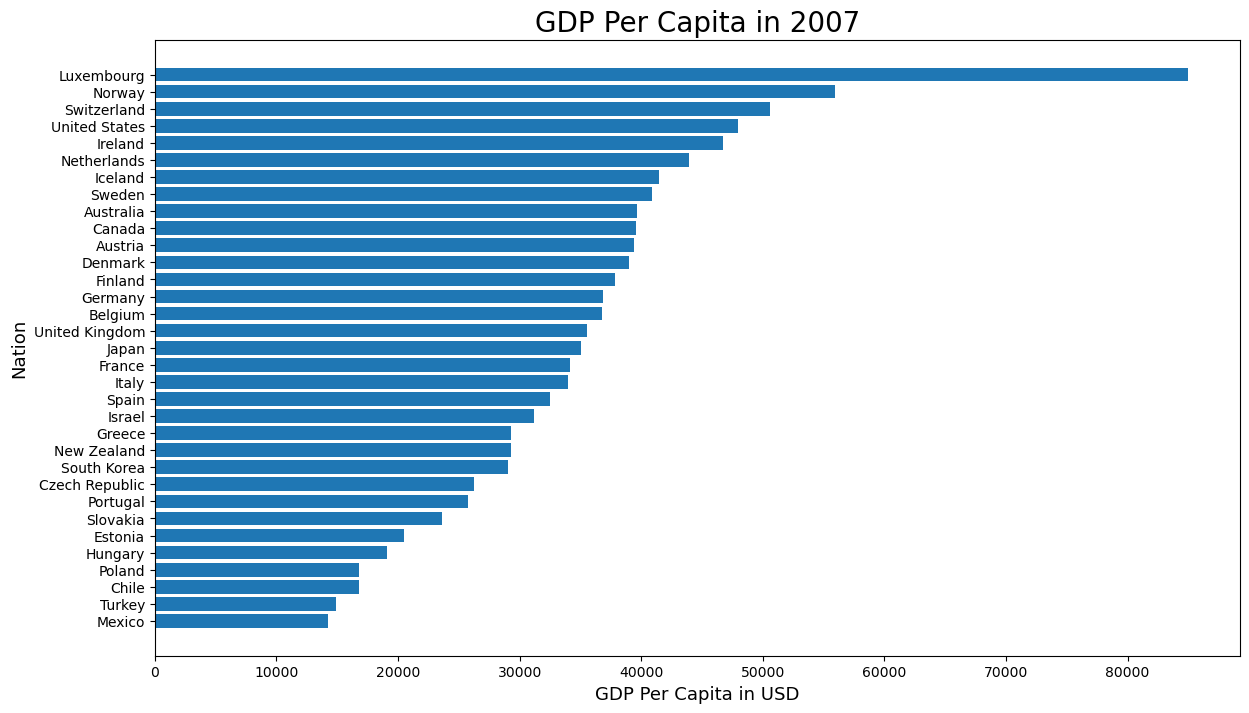

In [97]:
import matplotlib.pyplot as plt
OECD = OECD.sort_values(by = OECD.columns[2])

x = OECD["Country"]
y = OECD[OECD.columns[2]]

plt.figure(figsize = (14,8))
plt.barh(x,y)

plt.title(f"GDP Per Capita in {OECD.columns[2]}", fontsize = 20)
plt.xlabel("GDP Per Capita in USD", fontsize = 13)
plt.ylabel("Nation", fontsize = 13)
plt.show()

5. Compute the difference between GDP per capita for the 10 year interval.  Place this data as a new column in the same dataframe.  Sort the dataframe by the GDP growth and display the contents.

In [115]:
OECD["GDPGrowth"] = OECD[OECD.columns[2]] - OECD[OECD.columns[1]]
display(OECD.head())
display(OECD.tail())

,Country,1997,2007,GDPGrowth
32,Mexico,9456.139259,14215.81774,4759.678481
30,Turkey,11651.152830,14864.72187,3213.569040
31,Chile,8589.099500,16771.18290,8182.083400
27,Poland,9020.277064,16806.70684,7786.429776
28,Hungary,9825.036610,19096.40591,9271.369300


,Country,1997,2007,GDPGrowth
1,Ireland,22697.69291,46765.45015,24067.75724
4,United States,31424.43893,47976.20121,16551.76228
2,Switzerland,32441.52317,50583.78385,18142.26068
3,Norway,28610.24280,55938.55589,27328.31309
0,Luxembourg,42445.97140,84994.14541,42548.17401


6. Which country has the highest growth in GDP per capita?  Which had the smallest?

In [119]:
highest_growth = OECD.sort_values(by = OECD.columns[2], inplace = False, ascending = False).copy()
print(f"The country with the highest GDP per capita growth is {highest_growth.iloc[0]["Country"]}")
print(f"The country with the lowest GDP per capita growth is {highest_growth.iloc[-1]["Country"]}")

The country with the highest GDP per capita growth is Luxembourg
The country with the lowest GDP per capita growth is Mexico


7. Create a dataframe that contains a subset of the countries that had negative growth of their GDP per capita.  You should use Pandas comparisons and selection operators.  Display the resulting dataframe contents.

In [120]:
# none of the countries I am working with have negative GPD per capita growth. 

highest_growth.tail() #mexico is the smallest at $4,759 GPD per capita growth

,Country,1997,2007,GDPGrowth
28,Hungary,9825.036610,19096.40591,9271.369300
27,Poland,9020.277064,16806.70684,7786.429776
31,Chile,8589.099500,16771.18290,8182.083400
30,Turkey,11651.152830,14864.72187,3213.569040
32,Mexico,9456.139259,14215.81774,4759.678481


In [135]:
#I just decided to choose the ones below 7k in growth
lowest_growth = OECD[OECD["GDPGrowth"] < 10000].copy()
lowest_growth.sort_values(by = "GDPGrowth", ascending = True)
print(f"There are {len(lowest_growth.index)} nations with less than $10,000 in GDP per capita growth")
display(lowest_growth.head())
display(lowest_growth.tail())

There are 8 nations with less than $10,000 in GDP per capita growth


,Country,1997,2007,GDPGrowth
32,Mexico,9456.139259,14215.81774,4759.678481
30,Turkey,11651.152830,14864.72187,3213.569040
31,Chile,8589.099500,16771.18290,8182.083400
27,Poland,9020.277064,16806.70684,7786.429776
28,Hungary,9825.036610,19096.40591,9271.369300


,Country,1997,2007,GDPGrowth
27,Poland,9020.277064,16806.70684,7786.429776
28,Hungary,9825.036610,19096.40591,9271.369300
26,Portugal,15788.981350,25735.87316,9946.891810
21,Israel,25670.073210,31172.65097,5502.577760
17,Japan,25629.420660,35021.73222,9392.311560


8. Compute the Pearson correlation index between the GDP for the selected two columns in Task 2. Are the columns correlated? If so, how (weakly, strongly, etc.)?

In [142]:
OECD.iloc[:,1:3].corr()
#yes, these two columns are very strongly related
#the gdp of ten years prior is a huge factor in how large a country's GDP is now

,1997,2007
1997,1.000000,0.930168
2007,0.930168,1.000000


___
## <font color=orange>This is a Pandas Cheat Sheet</font>

![](https://i.pinimg.com/originals/39/08/5c/39085c27945ad3eb49e0de7dff6f0b0e.png)


___
![](https://media2.giphy.com/media/5nj4ZZWl6QwneEaBX4/source.gif) <br>

*Here are some of the resources used for creating this notebook:* 

- Pandas foundations. Retrieved February 15, 2021, from https://www.datacamp.com/courses/pandas-foundations <br>
- Pandas tutorial. Retrieved February 15, 2021, from https://www.w3schools.com/python/pandas/default.asp <br>
- Pandas tutorial: Dataframes in Python. Retrieved February 15, 2021, from https://www.datacamp.com/community/tutorials/pandas-tutorial-dataframe-python <br>

*Here are some great reads on this topic:* 
- __"Introduction to Pandas in Python"__ available at *https://www.geeksforgeeks.org/introduction-to-pandas-in-python/<br>
- __"Pandas Introduction & Tutorials for Beginners"__ by __Walker Rowe__, available at *https://www.bmc.com/blogs/pandas-basics/ <br>
- __"Using Pandas and Python to Explore Your Dataset"__ by __Reka Horvath__ available at *https://realpython.com/pandas-python-explore-dataset/ <br>
- __"Python Pandas Tutorial: A Complete Introduction for Beginners"__ by __George McIntire, Lauren Washington, and Brendan Martin__ available at *https://www.learndatasci.com/tutorials/python-pandas-tutorial-complete-introduction-for-beginners/ <br>


*Here are some great videos on these topics:* 
- __"Python: Pandas Tutorial | Intro to DataFrames"__ by __Joe James__ available at *https://www.youtube.com/watch?v=e60ItwlZTKM <br>
- __"Complete Python Pandas Data Science Tutorial! (Reading CSV/Excel files, Sorting, Filtering, Groupby)"__ by __Keith Galli__ available at *https://www.youtube.com/watch?v=vmEHCJofslg <br>
- __"What is Pandas? Why and How to Use Pandas in Python"__ by __Python Programmer__ available at *https://www.youtube.com/watch?v=dcqPhpY7tWk <br>


___

![](https://www.quotemaster.org/images/q/13084/1308445/i4.png)
![](https://images.fineartamerica.com/images/artworkimages/mediumlarge/2/bad-panda-balazs-solti.jpg)